C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2892\3174652925.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_cols)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2892\3174652925.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_cols)


SVR (base) -> R²: 0.676 | RMSE: 455.4

Mejores hiperparámetros: {'C': 10, 'epsilon': 0.05, 'gamma': 0.3}
SVR (best) -> R²: 0.860 | RMSE: 299.2


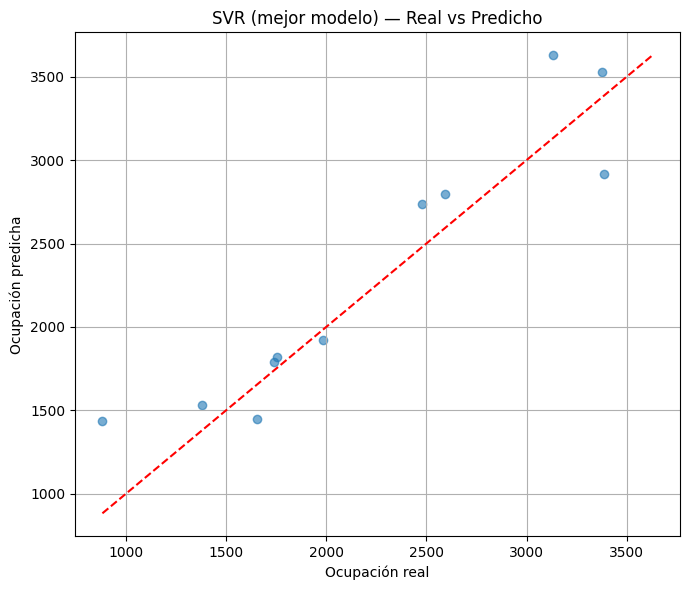

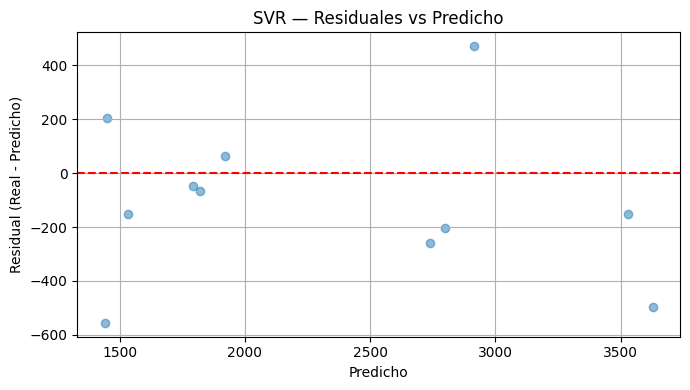


🎯 Predicción SVR (ejemplo manual): 1954 reservas/mes


In [2]:
# ============================================================
# SVM REGRESIÓN (SVR) COMPLETO — Ocupación mensual por hotel
# ============================================================

# 0) Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

# ---------------------------------------
# 1) CARGA Y PREPARACIÓN DEL DATASET BASE
# ---------------------------------------
df = pd.read_csv("data/hotel_bookings.csv")

# Asegurar numéricos en columnas que vamos a promediar
num_cols = [
    "lead_time","adr",
    "stays_in_week_nights","stays_in_weekend_nights",
    "total_of_special_requests"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Orden natural de meses (por si viene como texto)
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
df["arrival_date_month"] = pd.Categorical(df["arrival_date_month"],
                                          categories=month_order, ordered=True)

# 2) Construir dataset mensual (target = ocupación mensual, conteo de reservas)
group_cols = ["hotel","arrival_date_year","arrival_date_month"]

ocup = (
    df.groupby(group_cols)
      .size()
      .reset_index(name="ocupacion")
)

agg = (
    df.groupby(group_cols)
      .agg({
          "lead_time":"mean",
          "adr":"mean",
          "stays_in_week_nights":"mean",
          "stays_in_weekend_nights":"mean",
          "total_of_special_requests":"mean"
      })
      .reset_index()
)

data = ocup.merge(agg, on=group_cols, how="inner")

# Codificaciones generales
data["month_num"] = data["arrival_date_month"].cat.codes + 1
data["arrival_date_year"] = pd.to_numeric(data["arrival_date_year"], errors="coerce")

# hotel -> 0/1 (macro, no micro variables de cliente)
data["hotel"] = data["hotel"].map({"City Hotel":0, "Resort Hotel":1})

# ---------------------------
# 3) DEFINIR FEATURES Y TARGET
# ---------------------------
# Variables GENERALES (macro) coherentes con ocupación mensual
features = [
    "hotel","arrival_date_year","month_num",
    "lead_time","adr",
    "stays_in_week_nights","stays_in_weekend_nights",
    "total_of_special_requests"
]
target = "ocupacion"

model_df = data[features + [target]].dropna().copy()
X = model_df[features]
y = model_df[target]

# ------------------------------
# 4) SPLIT + ESCALADO (X e y)
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Escalamos X (siempre para SVR)
scaler_X = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)

# Escalamos y (MUY recomendable en SVR)
scaler_y = StandardScaler()
y_train_sc = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()

# ------------------------------------
# 5) ENTRENAMIENTO BÁSICO (SVR RBF)
# ------------------------------------
svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.2)
svr.fit(X_train_sc, y_train_sc)

# Predicción + desescalado de y
y_pred_sc = svr.predict(X_test_sc)
y_pred = scaler_y.inverse_transform(y_pred_sc.reshape(-1,1)).ravel()

r2_base = r2_score(y_test, y_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"SVR (base) -> R²: {r2_base:.3f} | RMSE: {rmse_base:.1f}")

# ------------------------------------
# 6) TUNING AUTOMÁTICO (GridSearchCV)
# ------------------------------------
# Rango compacto y razonable; podés ampliarlo si querés
param_grid = {
    "C": [10, 30, 100, 300, 1000],
    "gamma": ["scale", 0.3, 0.1, 0.03, 0.01],
    "epsilon": [0.05, 0.1, 0.2, 0.3]
}
grid = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=0
)
grid.fit(X_train_sc, y_train_sc)

best_svr = grid.best_estimator_
print("\nMejores hiperparámetros:", grid.best_params_)

# Re-entrenar con el mejor modelo y evaluar
y_pred_sc_best = best_svr.predict(X_test_sc)
y_pred_best = scaler_y.inverse_transform(y_pred_sc_best.reshape(-1,1)).ravel()

r2_best = r2_score(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
print(f"SVR (best) -> R²: {r2_best:.3f} | RMSE: {rmse_best:.1f}")

# ------------------------------------
# 7) GRÁFICOS DE DIAGNÓSTICO
# ------------------------------------
# Real vs Predicho
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_best, alpha=0.6)
mn, mx = min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel("Ocupación real")
plt.ylabel("Ocupación predicha")
plt.title("SVR (mejor modelo) — Real vs Predicho")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuales
resid = y_test - y_pred_best
plt.figure(figsize=(7,4))
plt.scatter(y_pred_best, resid, alpha=0.5)
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Predicho")
plt.ylabel("Residual (Real - Predicho)")
plt.title("SVR — Residuales vs Predicho")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------
# 8) FUNCIÓN DE PREDICCIÓN MANUAL
# ------------------------------------
def predecir_ocupacion_svr(registro_dict):
    """
    registro_dict: dict con las mismas claves que 'features'.
    Ejemplo:
      {
        "hotel": 1, "arrival_date_year": 2017, "month_num": 1,
        "lead_time": 75, "adr": 135.0,
        "stays_in_week_nights": 3, "stays_in_weekend_nights": 2,
        "total_of_special_requests": 1
      }
    """
    row = pd.DataFrame([registro_dict])[features]
    row_sc = scaler_X.transform(row)
    y_sc = best_svr.predict(row_sc).reshape(-1,1)
    y_hat = scaler_y.inverse_transform(y_sc).ravel()[0]
    # Evitar negativos (ocupación no puede ser negativa)
    return max(y_hat, 0.0)

# Ejemplo de uso:
ejemplo = {
    "hotel": 1,                      # 0=City, 1=Resort
    "arrival_date_year": 2017,
    "month_num": 1,                  # Enero
    "lead_time": 80,
    "adr": 140.0,
    "stays_in_week_nights": 3.0,
    "stays_in_weekend_nights": 2.0,
    "total_of_special_requests": 1.0
}
pred = predecir_ocupacion_svr(ejemplo)
print(f"\n🎯 Predicción SVR (ejemplo manual): {pred:.0f} reservas/mes")
